**Task 1: Build the Data Collection Pipeline**

**Step 1: Collect API Data**

In [1]:
import pandas as pd
import requests
import json


In [2]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)

In [3]:
print(response.status_code)

200


In [4]:
data = response.json()

print(data.keys())

dict_keys(['total_count', 'incomplete_results', 'items'])


**Step 2: Create the Dataset**

In [5]:
df = pd.DataFrame(data["items"])

In [6]:
print(df.head())

          id                           node_id                      name  \
0   45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==                tensorflow   
1  155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=              transformers   
2  343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=          ML-For-Beginners   
3  145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=                    funNLP   
4   21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==  awesome-machine-learning   

                               full_name  private  \
0                  tensorflow/tensorflow    False   
1               huggingface/transformers    False   
2             microsoft/ML-For-Beginners    False   
3                  fighting41love/funNLP    False   
4  josephmisiti/awesome-machine-learning    False   

                                               owner  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...   
1  {'login': 'huggingface', 'id': 25720743, 'node...   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...   


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [8]:
print(df.columns)

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [9]:
print(df.dtypes)

id                  int64
node_id            object
name               object
full_name          object
private              bool
                   ...   
forks               int64
open_issues         int64
watchers            int64
default_branch     object
score             float64
Length: 82, dtype: object


In [10]:
print(df.tail())

           id                           node_id  \
95  126573668  MDEwOlJlcG9zaXRvcnkxMjY1NzM2Njg=   
96  290234921  MDEwOlJlcG9zaXRvcnkyOTAyMzQ5MjE=   
97  123568881  MDEwOlJlcG9zaXRvcnkxMjM1Njg4ODE=   
98   17371412  MDEwOlJlcG9zaXRvcnkxNzM3MTQxMg==   
99  184701688  MDEwOlJlcG9zaXRvcnkxODQ3MDE2ODg=   

                                  name  \
95     Machine-learning-learning-notes   
96                   awesome-youtubers   
97  Learn_Machine_Learning_in_3_Months   
98                               h2o-3   
99           industry-machine-learning   

                                        full_name  private  \
95       Vay-keen/Machine-learning-learning-notes    False   
96                JoseDeFreitas/awesome-youtubers    False   
97  llSourcell/Learn_Machine_Learning_in_3_Months    False   
98                                    h2oai/h2o-3    False   
99               firmai/industry-machine-learning    False   

                                                owner  \
95  {'logi

In [11]:
print(df.shape)

(100, 82)


**Step 3: Select Required Columns**


In [12]:
columns = df[[
    "name", "owner", "language", "stargazers_count", "forks_count",
    "watchers_count", "open_issues_count", "created_at", "updated_at", "license"
]].copy()


In [13]:
print(columns.head())

                       name  \
0                tensorflow   
1              transformers   
2          ML-For-Beginners   
3                    funNLP   
4  awesome-machine-learning   

                                               owner          language  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...               C++   
1  {'login': 'huggingface', 'id': 25720743, 'node...            Python   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...  Jupyter Notebook   
3  {'login': 'fighting41love', 'id': 11475294, 'n...            Python   
4  {'login': 'josephmisiti', 'id': 246302, 'node_...            Python   

   stargazers_count  forks_count  watchers_count  open_issues_count  \
0            197375        76115          197375               2947   
1            164372        34334          164372               2407   
2             89713        22044           89713                 13   
3             82621        15274           82621                 52   
4            

In [14]:
print(columns.shape)

(100, 10)


**Step 4: Extract Required Values**


In [15]:
columns["owner"] = columns["owner"].apply(
    lambda x: x.get("login") if isinstance(x, dict) else None
)



In [16]:
print(columns["owner"])

0         tensorflow
1        huggingface
2          microsoft
3     fighting41love
4       josephmisiti
           ...      
95          Vay-keen
96     JoseDeFreitas
97        llSourcell
98             h2oai
99            firmai
Name: owner, Length: 100, dtype: object


In [17]:
columns["license"] = columns["license"].apply(
    lambda x: x.get("name") if isinstance(x, dict) else None
)

In [18]:
print(columns["license"])

0                       Apache License 2.0
1                       Apache License 2.0
2                              MIT License
3                                     None
4                                    Other
                      ...                 
95                                    None
96    Creative Commons Zero v1.0 Universal
97                                    None
98                      Apache License 2.0
99                                    None
Name: license, Length: 100, dtype: object


**Step 5: Handle Missing Values**


In [19]:
columns["language"] = columns["language"].fillna("Unknown")

In [20]:
columns["license"] = columns["license"].fillna("No License")

In [21]:
print(columns.isnull().sum())

name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


**Step 6: Handle Duplicate Records**


In [22]:
print( columns.duplicated().sum())

0


In [23]:
print( columns.shape)

(100, 10)


**Step 7: Prepare the Dataset**


In [24]:
columns["created_at"] = pd.to_datetime(columns["created_at"])

In [25]:
columns["updated_at"] = pd.to_datetime(columns["updated_at"])

In [26]:
columns = columns.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
})

In [27]:
print(columns)

                                  name           owner          language  \
0                           tensorflow      tensorflow               C++   
1                         transformers     huggingface            Python   
2                     ML-For-Beginners       microsoft  Jupyter Notebook   
3                               funNLP  fighting41love            Python   
4             awesome-machine-learning    josephmisiti            Python   
..                                 ...             ...               ...   
95     Machine-learning-learning-notes        Vay-keen           Unknown   
96                   awesome-youtubers   JoseDeFreitas          Markdown   
97  Learn_Machine_Learning_in_3_Months      llSourcell           Unknown   
98                               h2o-3           h2oai  Jupyter Notebook   
99           industry-machine-learning          firmai  Jupyter Notebook   

     stars  forks  watchers  open_issues              created_date  \
0   197375  76115

In [28]:
columns


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
1,transformers,huggingface,Python,164372,34334,164372,2407,2018-10-29 13:56:00+00:00,2026-08-23 20:12:58+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89713,22044,89713,13,2021-03-03 01:34:05+00:00,2026-08-23 20:42:00+00:00,MIT License
3,funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 20:18:05+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
95,Machine-learning-learning-notes,Vay-keen,Unknown,7761,1879,7761,28,2018-03-24 06:48:10+00:00,2026-08-21 04:15:39+00:00,No License
96,awesome-youtubers,JoseDeFreitas,Markdown,7745,498,7745,2,2020-08-25 14:18:15+00:00,2026-08-23 14:25:22+00:00,Creative Commons Zero v1.0 Universal
97,Learn_Machine_Learning_in_3_Months,llSourcell,Unknown,7603,2311,7603,19,2018-03-02 10:59:53+00:00,2026-08-21 16:08:33+00:00,No License
98,h2o-3,h2oai,Jupyter Notebook,7495,2025,7495,2883,2014-03-03 16:08:07+00:00,2026-08-21 06:04:07+00:00,Apache License 2.0


**Step 8: Save and Verify the Dataset**




In [29]:
columns.to_csv("github_projects.csv", index=False)

In [30]:
print(columns.shape)

(100, 10)


In [31]:
print(columns.columns)

Index(['name', 'owner', 'language', 'stars', 'forks', 'watchers',
       'open_issues', 'created_date', 'updated_date', 'license'],
      dtype='object')


In [32]:
github_projects = pd.read_csv("github_projects.csv")



In [33]:
print( github_projects.shape)

(100, 10)


In [34]:
print(github_projects.head())

                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197375  76115   
1              transformers     huggingface            Python  164372  34334   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89713  22044   
3                    funNLP  fighting41love            Python   82621  15274   
4  awesome-machine-learning    josephmisiti            Python   74132  15621   

   watchers  open_issues               created_date  \
0    197375         2947  2015-11-07 01:19:20+00:00   
1    164372         2407  2018-10-29 13:56:00+00:00   
2     89713           13  2021-03-03 01:34:05+00:00   
3     82621           52  2018-08-21 11:20:39+00:00   
4     74132           26  2014-07-15 19:11:19+00:00   

                updated_date             license  
0  2026-08-23 21:07:14+00:00  Apache License 2.0  
1  2026-08-23 20:12:58+00:00  Apache License 2.0  
2  2026-08-23 20:42:00+00:00       

In [35]:
print(github_projects.columns)

Index(['name', 'owner', 'language', 'stars', 'forks', 'watchers',
       'open_issues', 'created_date', 'updated_date', 'license'],
      dtype='object')


**Task 2 – Store and Analyze the Data**

*Step* 1: Create the SQLite Database
**bold text**

In [36]:
!pip install ipython-sql==0.5.0 prettytable==3.9.0

import sqlite3
%load_ext sql
%config SqlMagic.style = 'PLAIN_COLUMNS'
%sql sqlite:///github_projects.db

In [37]:
df=pd.read_csv("github_projects.csv")

conn = sqlite3.connect("github_projects.db")


df.to_sql("Repositories", conn, if_exists="replace", index=False)

100

**Step 2: Filtering & Searching Queries**

In [38]:
%%sql
SELECT *
FROM repositories

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
transformers,huggingface,Python,164372,34334,164372,2407,2018-10-29 13:56:00+00:00,2026-08-23 20:12:58+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89713,22044,89713,13,2021-03-03 01:34:05+00:00,2026-08-23 20:42:00+00:00,MIT License
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,No License
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 20:18:05+00:00,Other
scikit-learn,scikit-learn,Python,67034,27304,67034,2126,2010-08-17 09:43:38+00:00,2026-08-23 20:51:14+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36471,7461,36471,68,2021-01-02 12:08:37+00:00,2026-08-23 17:53:27+00:00,No License
C-Plus-Plus,TheAlgorithms,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,MIT License
netron,lutzroeder,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 20:20:02+00:00,MIT License


In [39]:
%%sql
SELECT *
FROM repositories
WHERE stars > 10000 ;

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
transformers,huggingface,Python,164372,34334,164372,2407,2018-10-29 13:56:00+00:00,2026-08-23 20:12:58+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89713,22044,89713,13,2021-03-03 01:34:05+00:00,2026-08-23 20:42:00+00:00,MIT License
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,No License
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 20:18:05+00:00,Other
scikit-learn,scikit-learn,Python,67034,27304,67034,2126,2010-08-17 09:43:38+00:00,2026-08-23 20:51:14+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36471,7461,36471,68,2021-01-02 12:08:37+00:00,2026-08-23 17:53:27+00:00,No License
C-Plus-Plus,TheAlgorithms,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,MIT License
netron,lutzroeder,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 20:20:02+00:00,MIT License


In [40]:
%%sql
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 20:18:05+00:00,Other
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36471,7461,36471,68,2021-01-02 12:08:37+00:00,2026-08-23 17:53:27+00:00,No License
machine-learning-for-software-engineers,ZuzooVn,Unknown,28869,6146,28869,32,2016-10-09 21:20:25+00:00,2026-08-23 19:47:14+00:00,Creative Commons Attribution Share Alike 4.0 International
homemade-machine-learning,trekhleb,Jupyter Notebook,24774,4194,24774,30,2018-11-01 04:34:19+00:00,2026-08-23 16:53:03+00:00,MIT License
awesome-production-machine-learning,EthicalML,Unknown,20865,2590,20865,31,2018-08-15 14:28:41+00:00,2026-08-23 20:12:49+00:00,MIT License
machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20593,5552,20593,3,2018-05-09 12:33:08+00:00,2026-08-23 20:49:13+00:00,MIT License
stanford-cs-229-machine-learning,afshinea,Unknown,20147,4252,20147,20,2018-08-04 23:01:00+00:00,2026-08-23 17:52:25+00:00,MIT License
Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3969,18140,47,2015-09-12 14:51:38+00:00,2026-08-23 13:27:46+00:00,Creative Commons Zero v1.0 Universal
machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13998,3103,13998,3,2020-04-17 04:29:23+00:00,2026-08-23 19:06:03+00:00,No License
machine-learning-interview,khangich,Unknown,12790,2045,12790,9,2020-08-11 06:26:32+00:00,2026-08-23 18:35:35+00:00,No License


**Step 3: Logical Operators**

In [41]:
%%sql
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%' AND forks > 100;

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 20:18:05+00:00,Other
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36471,7461,36471,68,2021-01-02 12:08:37+00:00,2026-08-23 17:53:27+00:00,No License
machine-learning-for-software-engineers,ZuzooVn,Unknown,28869,6146,28869,32,2016-10-09 21:20:25+00:00,2026-08-23 19:47:14+00:00,Creative Commons Attribution Share Alike 4.0 International
homemade-machine-learning,trekhleb,Jupyter Notebook,24774,4194,24774,30,2018-11-01 04:34:19+00:00,2026-08-23 16:53:03+00:00,MIT License
awesome-production-machine-learning,EthicalML,Unknown,20865,2590,20865,31,2018-08-15 14:28:41+00:00,2026-08-23 20:12:49+00:00,MIT License
machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20593,5552,20593,3,2018-05-09 12:33:08+00:00,2026-08-23 20:49:13+00:00,MIT License
stanford-cs-229-machine-learning,afshinea,Unknown,20147,4252,20147,20,2018-08-04 23:01:00+00:00,2026-08-23 17:52:25+00:00,MIT License
Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3969,18140,47,2015-09-12 14:51:38+00:00,2026-08-23 13:27:46+00:00,Creative Commons Zero v1.0 Universal
machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13998,3103,13998,3,2020-04-17 04:29:23+00:00,2026-08-23 19:06:03+00:00,No License
machine-learning-interview,khangich,Unknown,12790,2045,12790,9,2020-08-11 06:26:32+00:00,2026-08-23 18:35:35+00:00,No License


In [42]:
%%sql
SELECT *
FROM Repositories
WHERE language  = "Python"  OR license = "No License";

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
transformers,huggingface,Python,164372,34334,164372,2407,2018-10-29 13:56:00+00:00,2026-08-23 20:12:58+00:00,Apache License 2.0
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,No License
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 20:18:05+00:00,Other
scikit-learn,scikit-learn,Python,67034,27304,67034,2126,2010-08-17 09:43:38+00:00,2026-08-23 20:51:14+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36471,7461,36471,68,2021-01-02 12:08:37+00:00,2026-08-23 17:53:27+00:00,No License
ML-From-Scratch,eriklindernoren,Python,32514,5431,32514,77,2017-02-05 12:11:23+00:00,2026-08-23 20:21:19+00:00,MIT License
linkedin-skill-assessments-quizzes,Ebazhanov,Python,28806,12905,28806,21,2019-07-13 19:52:56+00:00,2026-08-23 19:50:04+00:00,GNU Affero General Public License v3.0
cs249r_book,harvard-edge,Python,27988,3534,27988,27,2023-09-06 19:31:06+00:00,2026-08-23 15:24:03+00:00,Other
onnx,onnx,Python,21349,4007,21349,287,2017-09-07 04:53:45+00:00,2026-08-23 18:11:47+00:00,Apache License 2.0


In [43]:
%%sql
SELECT *
FROM Repositories
WHERE language = 'Python'
OR language = 'JavaScript';

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
transformers,huggingface,Python,164372,34334,164372,2407,2018-10-29 13:56:00+00:00,2026-08-23 20:12:58+00:00,Apache License 2.0
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,No License
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 20:18:05+00:00,Other
scikit-learn,scikit-learn,Python,67034,27304,67034,2126,2010-08-17 09:43:38+00:00,2026-08-23 20:51:14+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,Apache License 2.0
netron,lutzroeder,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 20:20:02+00:00,MIT License
ML-From-Scratch,eriklindernoren,Python,32514,5431,32514,77,2017-02-05 12:11:23+00:00,2026-08-23 20:21:19+00:00,MIT License
linkedin-skill-assessments-quizzes,Ebazhanov,Python,28806,12905,28806,21,2019-07-13 19:52:56+00:00,2026-08-23 19:50:04+00:00,GNU Affero General Public License v3.0
cs249r_book,harvard-edge,Python,27988,3534,27988,27,2023-09-06 19:31:06+00:00,2026-08-23 15:24:03+00:00,Other
onnx,onnx,Python,21349,4007,21349,287,2017-09-07 04:53:45+00:00,2026-08-23 18:11:47+00:00,Apache License 2.0


In [44]:
%%sql
SELECT *
FROM Repositories
WHERE open_issues NOT BETWEEN 0 AND 10;

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
transformers,huggingface,Python,164372,34334,164372,2407,2018-10-29 13:56:00+00:00,2026-08-23 20:12:58+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89713,22044,89713,13,2021-03-03 01:34:05+00:00,2026-08-23 20:42:00+00:00,MIT License
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,No License
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 20:18:05+00:00,Other
scikit-learn,scikit-learn,Python,67034,27304,67034,2126,2010-08-17 09:43:38+00:00,2026-08-23 20:51:14+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36471,7461,36471,68,2021-01-02 12:08:37+00:00,2026-08-23 17:53:27+00:00,No License
C-Plus-Plus,TheAlgorithms,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,MIT License
netron,lutzroeder,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 20:20:02+00:00,MIT License



**Step 4: Sorting & Limiting Queries**




In [45]:
%%sql
SELECT *
FROM Repositories
ORDER BY stars DESC
LIMIT 10;

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
transformers,huggingface,Python,164372,34334,164372,2407,2018-10-29 13:56:00+00:00,2026-08-23 20:12:58+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89713,22044,89713,13,2021-03-03 01:34:05+00:00,2026-08-23 20:42:00+00:00,MIT License
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,No License
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 20:18:05+00:00,Other
scikit-learn,scikit-learn,Python,67034,27304,67034,2126,2010-08-17 09:43:38+00:00,2026-08-23 20:51:14+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36471,7461,36471,68,2021-01-02 12:08:37+00:00,2026-08-23 17:53:27+00:00,No License
C-Plus-Plus,TheAlgorithms,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,MIT License
netron,lutzroeder,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 20:20:02+00:00,MIT License


**Step 5: Aggregate Functions**


In [46]:
%%sql
SELECT
COUNT(*) AS total_count
FROM Repositories

 * sqlite:///github_projects.db
Done.


total_count
100


In [47]:
%%sql
SELECT
AVG(stars) AS average_stars
FROM Repositories

 * sqlite:///github_projects.db
Done.


average_stars
20825.61


**Step 6: Grouping Analysis**


In [48]:
%%sql
SELECT language,
 COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;

 * sqlite:///github_projects.db
Done.


language,repository_count
Python,30
Unknown,23
Jupyter Notebook,19
C++,12


**Step 7: Create Python Visualizations**






In [49]:
import matplotlib.pyplot as plt


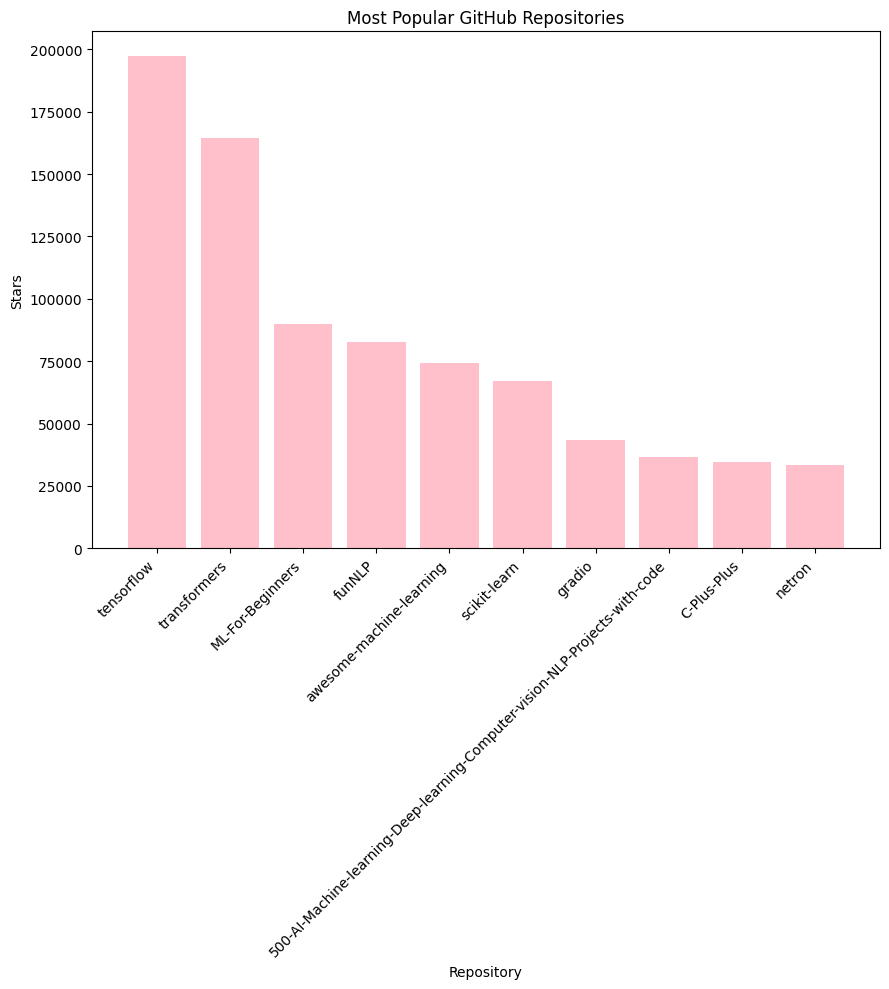

In [50]:
plt.figure(figsize=(9, 10))
popular = df.sort_values("stars", ascending=False).head(10)

plt.bar(popular["name"], popular["stars"],color="pink")

plt.xlabel("Repository")
plt.ylabel("Stars")
plt.title("Most Popular GitHub Repositories")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

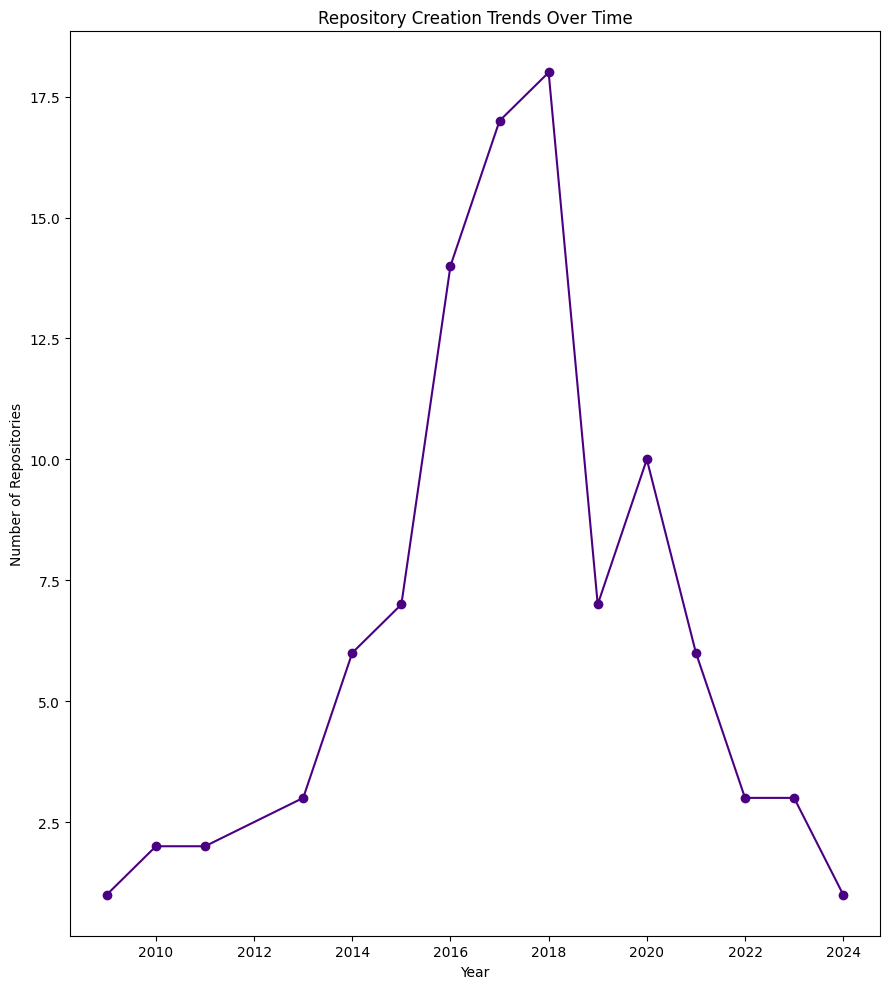

In [51]:
df["created_date"] = pd.to_datetime(df["created_date"])

yearly = df.groupby(df["created_date"].dt.year).size()

plt.figure(figsize=(9, 10))

plt.plot(yearly.index, yearly.values, marker="o" , color= "indigo")

plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.title("Repository Creation Trends Over Time")

plt.tight_layout()
plt.show()

**Step 8: Interpret Results**


**Important patterns:**

A few repos are way more popular than the rest — tensorflow has 197,330 stars and transformers has 164,344, both way ahead of everyone else. The third most popular repo only has 89,688 stars, less than half of what transformers has. After that the numbers keep dropping, so it's really just those top two or three repos in their own league. Python is the most used language by far with 30 repos, followed by repos with no listed language, then Jupyter Notebook and C++ — this shows Python is basically the go-to language for ML. A lot of repos are learning resources and not just code — 30 have "machine" in the name and many are tutorials, cheat sheets, or courses instead of libraries. Not everyone adds a license either: 78 out of 100 have one, but 22 don't, which matters if someone wants to actually reuse the code.

**Trends in the data:**

Most of these repos were created around 2016 to 2018, with 2018 being the busiest year — that matches when machine learning really started blowing up. Fewer repos have been made since 2020, probably because newer repos haven't had time to get as popular yet.

**Useful insights that answer the business questions:**

Most repos here are already popular — 70 out of 100 have over 10,000 stars. This makes sense since the data is sorted by stars, so it's biased toward big, well-known projects. Overall, the most popular ML repos tend to be big, Python-based, and often built for learning or teaching, with most of them made during the 2016–2018 ML boom.

**Task 3 – Manage the Project Using Git and GitHub**

**Step 7 Complete the Ethics Reflection**


**Why is it important to verify data collected from public APIs?**

APIs can return data that's incomplete, outdated, or just wrong — fields can be missing, rate limits can cut off results, or the API itself might have bugs. If you use that data without checking it first, any analysis built on it could be misleading.
You should check nulls, duplicates, weird values and make sure that you solve any of this problems if they were exist

**Why should data analysts document the source of their data?**

Documenting the source lets other people  know exactly where the data came from, when it was pulled, and what it does or doesn't include. This matters because data changes over time,  so without documentation, nobody can reproduce or verify the analysis later. It also helps explain any bias in the data .

**How can missing or inaccurate data affect data analysis and decision-making?**

Missing or wrong data can quietly skew results . If decisions are made based on that flawed data, the mistakes carry forward and can lead to bad conclusions . That's why handling missing values properly is such an important step before doing any real analysis.

**Github repo link**

the link:  

https://github.com/faridahisham999-cloud/github-ml-repo-analysis